# Reinforcement Learning with Keras


## 1. What is reinforcement learning?

Reinforcement learning is a learning setup where an agent interacts with an environment and learns by trial and error.

The agent does not learn from labeled input-output pairs like in supervised learning.

Instead, the loop is:

1. observe the current state
2. choose an action
3. receive a reward
4. move to a new state
5. repeat

The goal is to learn a strategy that maximizes long-term reward.

This is a very important shift in thinking.

In supervised learning, the target is given.

In reinforcement learning, the agent must discover good behavior by interacting with the environment and observing consequences.


## 2. Core concepts

Before writing any code, you need the main vocabulary clear.

### State
The current situation observed by the agent.

### Action
A decision the agent can take.

### Reward
A scalar signal telling the agent whether an action was good or bad.

### Episode
One full run from start until termination.

### Policy
The strategy used to choose actions.

### Return
The total accumulated reward over time.

### Exploration vs exploitation
The agent must balance:

- trying new actions to discover better behavior
- using known good actions to maximize reward


## 3. Why use Gymnasium?

A reinforcement learning agent needs an environment.

Gymnasium provides standardized environments so you can focus on the learning algorithm instead of building the world from scratch.

We will use `CartPole-v1`, a classic environment where:

- a pole is attached to a moving cart
- the agent can push left or right
- the goal is to keep the pole balanced




## 4. What algorithm will we build?

We will build a simple Deep Q-Network style agent.

The main idea is:

- use a neural network to estimate Q-values
- a Q-value means: how good is a given action in a given state?
- the agent chooses actions based on these predicted Q-values

## 5. Import the libraries



In [1]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

## 6. Create and inspect the environment



In [17]:
env = gym.make("CartPole-v1")

state_shape = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)
learning_rate = float(0.001)

print("State size:", state_shape)
print("Action size:", action_size)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

State size: 4
Action size: 2
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 7. Understand the state and action space

For `CartPole-v1`, the state is a vector of four values representing the physical condition of the cart-pole system.

The action space is discrete:

- action `0`
- action `1`

The agent must learn which action is better for each observed state.


## 8. Define hyperparameters



In [12]:
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
learning_rate = 0.001

batch_size = 64
memory_size = 2000
episodes = 200
max_steps_per_episode = 500

## 9. Build the Q-network with Keras

We now build the neural network.

Input:
- current state vector

Output:
- one Q-value per possible action

The model predicts how useful each action is in the current state.



In [19]:
def build_q_network(state_shape, action_size, learning_rate):
    print("state_shape =", state_shape, type(state_shape))
    print("action_size =", action_size, type(action_size))
    print("learning_rate =", learning_rate, type(learning_rate))

    model = keras.Sequential([
        layers.Input(shape=(state_shape,)),
        layers.Dense(24, activation="relu"),
        layers.Dense(24, activation="relu"),
        layers.Dense(action_size, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model

learning_rate = 0.001

model = build_q_network(state_shape, action_size, learning_rate)
model.summary()

 Non-trainable params: 0 (0.00 B)

## 11. Define the agent class

Now we wrap the main RL logic into an agent class.

The agent will handle:

- building the model
- storing experience
- choosing actions
- training from replay memory
- updating exploration behavior

In [22]:
class DQNAgent:
    def __init__(
        self,
        state_shape,
        action_size,
        learning_rate,
        gamma,
        epsilon,
        epsilon_min,
        epsilon_decay,
        memory_size
    ):
        self.state_shape = state_shape
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.memory = deque(maxlen=memory_size)

        self.model = build_q_network(state_shape, action_size, learning_rate)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)

        states = []
        targets = []

        for state, action, reward, next_state, done in minibatch:
            target = self.model.predict(state, verbose=0)[0]

            if done:
                target[action] = reward
            else:
                next_q_values = self.model.predict(next_state, verbose=0)[0]
                target[action] = reward + self.gamma * np.max(next_q_values)

            states.append(state[0])
            targets.append(target)

        states = np.array(states)
        targets = np.array(targets)

        self.model.fit(states, targets, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [23]:
agent = DQNAgent(
    state_shape=state_shape,
    action_size=action_size,
    learning_rate=learning_rate,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    memory_size=memory_size
)

state_shape = 4 <class 'int'>
action_size = 2 <class 'int'>
learning_rate = 0.001 <class 'float'>


## 14. Run the training loop

Now we train over many episodes.

For each episode:

1. reset the environment
2. repeatedly choose actions
3. step through the environment
4. store experience
5. train from replay memory
6. track total reward



In [24]:
episode_rewards = []

for episode in range(episodes):
    state, info = env.reset()
    state = np.reshape(state, [1, state_shape])

    total_reward = 0

    for step in range(max_steps_per_episode):
        action = agent.act(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state = np.reshape(next_state, [1, state_shape])

        agent.remember(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if done:
            break

    agent.replay(batch_size)
    episode_rewards.append(total_reward)

    print(
        f"Episode {episode + 1}/{episodes} - "
        f"Reward: {total_reward} - "
        f"Epsilon: {agent.epsilon:.4f}"
    )

Episode 200/200 - Reward: 12.0 - Epsilon: 0.3725


## 15. Track rewards over time


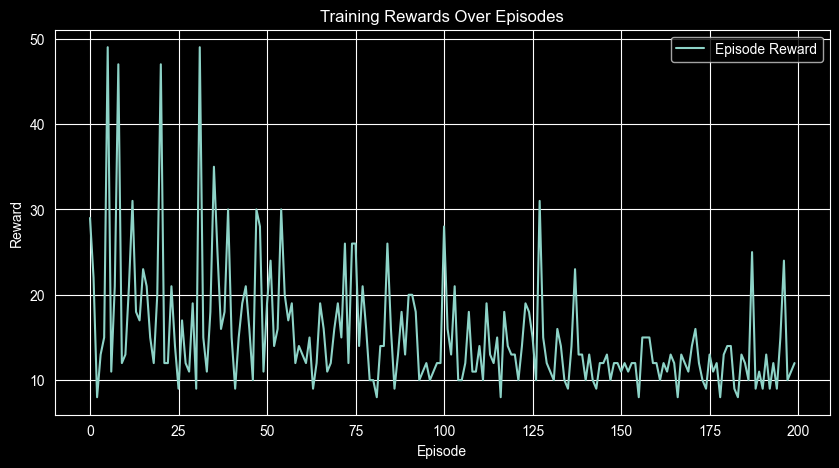

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards Over Episodes")
plt.legend()
plt.show()

## 17. Evaluate the trained agent



In [27]:
evaluation_episodes = 10
evaluation_rewards = []

for episode in range(evaluation_episodes):
    state, info = env.reset()
    state = np.reshape(state, [1, state_shape])

    total_reward = 0
    done = False

    while not done:
        q_values = agent.model.predict(state, verbose=0)
        action = np.argmax(q_values[0])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state = np.reshape(next_state, [1, state_shape])
        state = next_state
        total_reward += reward

    evaluation_rewards.append(total_reward)
    print(f"Evaluation Episode {episode + 1}: Reward = {total_reward}")

print("Average evaluation reward:", np.mean(evaluation_rewards))

Evaluation Episode 10: Reward = 9.0
Average evaluation reward: 9.3


## Visualize one evaluation episode



In [25]:
render_env = gym.make("CartPole-v1", render_mode="human")

state, info = render_env.reset()
state = np.reshape(state, [1, state_shape])

done = False
total_reward = 0

while not done:
    q_values = agent.model.predict(state, verbose=0)
    action = np.argmax(q_values[0])

    next_state, reward, terminated, truncated, info = render_env.step(action)
    done = terminated or truncated

    next_state = np.reshape(next_state, [1, state_shape])
    state = next_state
    total_reward += reward

print("Rendered episode reward:", total_reward)
render_env.close()

Rendered episode reward: 9.0
